# 03_s3 — Stream 3 data corrected + `_s3` log-signatures for SigCWGAN

This notebook is the **preparation notebook** for Stream 3.

It does **not** train the SigCWGAN itself. Instead it:

1. reads the authoritative Stream-2 fixtures,
2. restores the full Stream-3 conditioning c,
3. computes **new `_s3` log-signatures**,
4. builds the **19-dimensional conditioning vector**,
5. reuses the **hazard split metadata** for train / val / test,
6. writes out `_s3` artifacts for Notebook 4.

###  carried in from the current CUE

- Layer 2 is the shipped **spike / negative hazard process**, not Hawkes.
- Segment regimes for downstream conditioning use **`regime_refined`**.
- The conditioning vector is **19-dimensional**:
  - 7 econometric scalars,
  - 9-way one-hot `regime_refined`,
  - 3 hazard segment features.
- `har_rv_prev_mean` is restored explicitly if it is absent from the saved JSON / segment file.

### Outputs

- `logsigs_s3.parquet`
- `norm_stats_s3.json`
- `conditioning_stats_s3.json`

Notebook 4 should read `logsigs_s3.parquet` as its primary training table.

### Setup & imports

In [2]:
%pip install -q iisignature polars pyarrow matplotlib numpy pandas scikit-learn

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
import polars as pl
import iisignature
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.30,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Data directory: {DATA_DIR}")
print(f"iisignature version: {iisignature.__version__}")

Mounted at /content/drive
Data directory: /content/drive/MyDrive/energy_synthetic_data/data
iisignature version: 0.24


### CELL 1 — Load authoritative inputs

In [3]:
# Core upstream fixtures
seg = pl.read_parquet(DATA_DIR / "segments_s2.parquet")
master = pl.read_parquet(DATA_DIR / "master.parquet").sort("start_time")
haz_seg = pl.read_parquet(DATA_DIR / "hazard_features_seg.parquet")

with open(DATA_DIR / "hazard_fit.json", "r") as fp:
    hazard_fit = json.load(fp)

with open(DATA_DIR / "feature_analysis_s2.json", "r") as fp:
    feature_analysis = json.load(fp)

seg_pd = seg.to_pandas()
master_pd = master.to_pandas()
haz_seg_pd = haz_seg.to_pandas()

if seg_pd["start_time"].dtype == object:
    seg_pd["start_time"] = pd.to_datetime(seg_pd["start_time"])
if master_pd["start_time"].dtype == object:
    master_pd["start_time"] = pd.to_datetime(master_pd["start_time"])

print(f"segments_s2.parquet:        {seg_pd.shape[0]:,} rows × {seg_pd.shape[1]} cols")
print(f"master.parquet:             {master_pd.shape[0]:,} rows × {master_pd.shape[1]} cols")
print(f"hazard_features_seg.parquet:{haz_seg_pd.shape[0]:,} rows × {haz_seg_pd.shape[1]} cols")
print(f"Winning label scheme in JSON: {feature_analysis.get('winning_label_scheme')}")
print(f"Conditioning vars in saved JSON: {feature_analysis.get('conditioning_variables')}")

segments_s2.parquet:        6,530 rows × 75 cols
master.parquet:             157,776 rows × 96 cols
hazard_features_seg.parquet:6,530 rows × 5 cols
Winning label scheme in JSON: regime_refined
Conditioning vars in saved JSON: ['nuclear_prev_mean', 'wind_prev_mean', 'RV_prev', 'ccgt_fraction_prev_mean', 'ocgt_active_prev_mean', 'wind_var_prev_mean']


### CELL 2 — Parameters and stream contract

In [4]:
STREAM_TAG = "s3"

SEGMENT_LENGTH = 72   # 36 hours
STEP_SIZE = 24        # 12 hours
SIG_DEPTH = 4
USE_LEAD_LAG = True

LOGSIG_OUT = DATA_DIR / f"logsigs_{STREAM_TAG}.parquet"
NORM_OUT = DATA_DIR / f"norm_stats_{STREAM_TAG}.json"
COND_STATS_OUT = DATA_DIR / f"conditioning_stats_{STREAM_TAG}.json"

PRICE_COL = "mid_price"
WIND_COL = (
    "total_wind_full_mw"
    if "total_wind_full_mw" in master_pd.columns
    else "total_wind_mw"
    if "total_wind_mw" in master_pd.columns
    else "wind"
)

REGIME_COL = "regime_refined"
HAZARD_SEG_COLS = [
    "seg_lambda_spike_mean",
    "seg_lambda_neg_mean",
    "seg_lambda_spike_max",
]
ECON_COLS_TARGET = [
    "nuclear_prev_mean",
    "wind_prev_mean",
    "RV_prev",
    "ccgt_fraction_prev_mean",
    "ocgt_active_prev_mean",
    "wind_var_prev_mean",
    "har_rv_prev_mean",
]

assert REGIME_COL in seg_pd.columns, f"{REGIME_COL} missing from segments_s2.parquet"
for c in HAZARD_SEG_COLS:
    assert c in haz_seg_pd.columns, f"{c} missing from hazard_features_seg.parquet"

print(f"Price column: {PRICE_COL}")
print(f"Wind column:  {WIND_COL}")
print(f"Regime col:   {REGIME_COL}")
print(f"Target econometric scalar block ({len(ECON_COLS_TARGET)} dims): {ECON_COLS_TARGET}")
print(f"Hazard segment block ({len(HAZARD_SEG_COLS)} dims): {HAZARD_SEG_COLS}")

Price column: mid_price
Wind column:  total_wind_full_mw
Regime col:   regime_refined
Target econometric scalar block (7 dims): ['nuclear_prev_mean', 'wind_prev_mean', 'RV_prev', 'ccgt_fraction_prev_mean', 'ocgt_active_prev_mean', 'wind_var_prev_mean', 'har_rv_prev_mean']
Hazard segment block (3 dims): ['seg_lambda_spike_mean', 'seg_lambda_neg_mean', 'seg_lambda_spike_max']


### CELL 3 — Helper functions

In [5]:
def lead_lag_transform(x: np.ndarray) -> np.ndarray:
    T = len(x)
    path = np.zeros((2 * (T - 1), 2), dtype=np.float64)
    for k in range(T - 1):
        path[2 * k] = [x[k], x[k]]
        path[2 * k + 1] = [x[k + 1], x[k]]
    return path


def safe_standardise_within_segment(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    x = np.nan_to_num(x, nan=np.nanmedian(x) if np.isfinite(x).any() else 0.0)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if not np.isfinite(sd) or sd < 1e-8:
        return x - mu
    return (x - mu) / sd


def build_path(price_seg: np.ndarray, wind_seg: np.ndarray, use_lead_lag: bool = True) -> np.ndarray:
    p_norm = safe_standardise_within_segment(price_seg)
    w_norm = safe_standardise_within_segment(wind_seg)

    if use_lead_lag:
        ll = lead_lag_transform(p_norm)
        t_ll = np.linspace(0.0, 1.0, len(ll))
        w_ll = np.interp(t_ll, np.linspace(0.0, 1.0, len(w_norm)), w_norm)
        return np.column_stack([t_ll, ll, w_ll])

    t = np.linspace(0.0, 1.0, len(p_norm))
    return np.column_stack([t, p_norm, w_norm])


def zscore_fit(x: pd.Series) -> dict:
    arr = pd.to_numeric(x, errors="coerce").to_numpy(dtype=np.float64)
    mu = np.nanmean(arr)
    sd = np.nanstd(arr)
    if not np.isfinite(sd) or sd < 1e-8:
        sd = 1.0
    return {"mean": float(mu), "std": float(sd)}


def zscore_apply(x: pd.Series, stats: dict) -> pd.Series:
    arr = pd.to_numeric(x, errors="coerce").to_numpy(dtype=np.float64)
    return pd.Series((arr - stats["mean"]) / stats["std"], index=x.index)


def parse_split_policy_meta(hfit: dict) -> dict:
    sp = hfit.get("split_policy", {}) if isinstance(hfit, dict) else {}
    return {
        "train_frac": float(sp.get("train_frac", 0.70)),
        "val_frac": float(sp.get("val_frac", 0.15)),
        "test_frac": float(sp.get("test_frac", 0.15)),
        "embargo_bins": int(sp.get("embargo_bins", SEGMENT_LENGTH)),
        "train_range": sp.get("train_range"),
        "val_range": sp.get("val_range"),
        "test_range": sp.get("test_range"),
    }


def recompute_blocked_segment_split(
    seg_df: pd.DataFrame,
    train_frac: float = 0.70,
    val_frac: float = 0.15,
    test_frac: float = 0.15,
    segment_length: int = SEGMENT_LENGTH,
    step_size: int = STEP_SIZE,
    embargo_bins: int = SEGMENT_LENGTH,
) -> pd.Series:
    """
    Defensive chronological split on segment order / start_idx.

    Why this exists:
    hazard_fit.json stores min/max timestamps for train/val/test, but the upstream
    hazard notebook produced those splits from interleaved chunk assignments rather
    than contiguous chronological blocks. Interpreting those min/max timestamps as
    contiguous date windows collapses almost everything into the first matching split.

    We therefore rebuild a proper blocked split directly from ordered segments and
    apply an overlap-aware embargo around the train/val and val/test boundaries.
    """
    if not np.isclose(train_frac + val_frac + test_frac, 1.0):
        raise ValueError("train/val/test fractions must sum to 1.")

    df_sorted = seg_df.sort_values(["start_idx", "end_idx", "start_time"]).reset_index()
    n = len(df_sorted)

    n_train = int(np.floor(train_frac * n))
    n_val = int(np.floor(val_frac * n))
    n_test = n - n_train - n_val

    if min(n_train, n_val, n_test) <= 0:
        raise ValueError(
            f"Invalid split sizes from n={n}: train={n_train}, val={n_val}, test={n_test}"
        )

    b1 = n_train
    b2 = n_train + n_val

    boundary1 = int(df_sorted.loc[b1, "start_idx"])
    boundary2 = int(df_sorted.loc[b2, "start_idx"])

    labels = np.full(n, "embargo", dtype=object)

    start_idx = pd.to_numeric(df_sorted["start_idx"], errors="raise").to_numpy(dtype=np.int64)
    end_idx = pd.to_numeric(df_sorted["end_idx"], errors="raise").to_numpy(dtype=np.int64)

    # A right-hand segment must start at least embargo_bins after the boundary.
    # A left-hand segment must finish at least embargo_bins before the boundary.
    train_keep = end_idx <= (boundary1 - embargo_bins)
    val_keep = (start_idx >= (boundary1 + embargo_bins)) & (end_idx <= (boundary2 - embargo_bins))
    test_keep = start_idx >= (boundary2 + embargo_bins)

    labels[train_keep] = "train"
    labels[val_keep] = "val"
    labels[test_keep] = "test"

    out = pd.Series(labels, index=df_sorted["index"])
    out = out.reindex(seg_df.index)

    return out


def first_existing(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    raise KeyError(f"None of the candidate columns found: {candidates}")


### CELL 4 — Reuse hazard split metadata

In [6]:
split_meta = parse_split_policy_meta(hazard_fit)

print("Legacy split metadata from hazard_fit.json (for diagnostics only):")
for split in ["train", "val", "test"]:
    print(f"  {split}: {split_meta.get(split + '_range')}")

seg_pd = seg_pd.sort_values(["start_idx", "end_idx", "start_time"]).reset_index(drop=True).copy()
seg_pd["split_legacy"] = seg_pd.get("split", pd.Series(index=seg_pd.index, dtype=object))

seg_pd["split"] = recompute_blocked_segment_split(
    seg_pd,
    train_frac=split_meta["train_frac"],
    val_frac=split_meta["val_frac"],
    test_frac=split_meta["test_frac"],
    segment_length=SEGMENT_LENGTH,
    step_size=STEP_SIZE,
    embargo_bins=split_meta["embargo_bins"],
)

print("\nRecomputed chronological segment split:")
print(seg_pd["split"].value_counts(dropna=False))

if "split_legacy" in seg_pd.columns and seg_pd["split_legacy"].notna().any():
    agree = (seg_pd["split"] == seg_pd["split_legacy"]).mean()
    print(f"Agreement with any pre-existing segment split column: {agree:.3f}")

valid_splits = {"train", "val", "test", "embargo"}
bad_labels = sorted(set(seg_pd["split"].dropna().unique()) - valid_splits)
if bad_labels:
    raise ValueError(f"Unexpected split labels after recompute: {bad_labels}")

n_train = int((seg_pd["split"] == "train").sum())
n_val = int((seg_pd["split"] == "val").sum())
n_test = int((seg_pd["split"] == "test").sum())

if min(n_train, n_val, n_test) <= 0:
    raise RuntimeError(
        f"Bad recomputed split sizes: train={n_train}, val={n_val}, test={n_test}"
    )

print("\nTime coverage by recomputed split:")
for lab in ["train", "val", "test", "embargo"]:
    tmp = pd.to_datetime(seg_pd.loc[seg_pd["split"] == lab, "start_time"])
    if len(tmp) == 0:
        print(f"  {lab:7s}: n=0")
    else:
        print(f"  {lab:7s}: n={len(tmp):4d} | {tmp.min()} -> {tmp.max()}")


Legacy split metadata from hazard_fit.json (for diagnostics only):
  train: ['2017-04-02 00:00:00+00:00', '2025-12-13 23:30:00+00:00']
  val: ['2017-01-01 00:00:00+00:00', '2025-09-20 23:30:00+00:00']
  test: ['2018-08-19 00:00:00+00:00', '2025-12-30 11:30:00+00:00']

Recomputed chronological segment split:
split
train      4566
test        977
val         971
embargo      16
Name: count, dtype: int64

Time coverage by recomputed split:
  train  : n=4566 | 2017-01-01 12:00:00+00:00 -> 2023-04-23 00:00:00+00:00
  val    : n= 971 | 2023-04-27 12:00:00+00:00 -> 2024-08-24 12:00:00+00:00
  test   : n= 977 | 2024-08-29 00:00:00+00:00 -> 2025-12-30 00:00:00+00:00
  embargo: n=  16 | 2023-04-23 12:00:00+00:00 -> 2024-08-28 12:00:00+00:00


### CELL 5 — Restore / compute the 7 econometric scalars

In [7]:
master_pd = master_pd.sort_values("start_time").reset_index(drop=True)

DAY_BINS = 48
WEEK_BINS = 48 * 7
MONTH_BINS = 48 * 30
SEG_LEN = SEGMENT_LENGTH

def _first_existing_or_none(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

def _require_any(cols, candidates, label):
    hit = _first_existing_or_none(cols, candidates)
    if hit is None:
        raise KeyError(
            f"Could not find a column for {label}. Tried: {candidates}\n"
            f"Available columns include: {list(cols)[:80]}"
        )
    return hit

def _infer_price_col(df):
    cols = list(df.columns)

    # 1) respect PRICE_COL if already set and valid
    if "PRICE_COL" in globals() and PRICE_COL in df.columns:
        return PRICE_COL

    # 2) explicit candidates first
    explicit = [
        "day_ahead_price",
        "price",
        "electricity_price",
        "spot_price",
        "system_price",
        "market_price",
        "price_gbp_mwh",
        "dam_price",
        "da_price",
        "smp",
    ]
    hit = _first_existing_or_none(cols, explicit)
    if hit is not None:
        return hit

    # 3) any numeric-looking price column
    price_like = [
        c for c in cols
        if ("price" in c.lower() or c.lower() in {"smp", "dam_price", "da_price"})
    ]
    if price_like:
        return price_like[0]

    raise KeyError(
        "No usable price column found in master.parquet. "
        f"Available columns include: {cols[:80]}"
    )

# Resolve the key master columns robustly
PRICE_COL = _infer_price_col(master_pd)
WIND_MASTER_COL = _first_existing_or_none(
    master_pd.columns,
    [WIND_COL, "total_wind_full_mw", "total_wind_mw", "wind", "wind_mw"]
)
if WIND_MASTER_COL is None:
    raise KeyError(
        f"Could not resolve wind column in master.parquet. Tried "
        f"[WIND_COL={globals().get('WIND_COL', None)}, 'total_wind_full_mw', "
        f"'total_wind_mw', 'wind', 'wind_mw']"
    )

nuclear_col = _require_any(
    master_pd.columns,
    ["nuclear", "nuclear_mw"],
    "nuclear"
)
ccgt_col = _require_any(
    master_pd.columns,
    ["ccgt", "ccgt_mw"],
    "ccgt"
)
ocgt_col = _require_any(
    master_pd.columns,
    ["ocgt", "ocgt_mw"],
    "ocgt"
)
total_gen_col = _require_any(
    master_pd.columns,
    ["total_generation_mw", "total_generation", "generation_total_mw"],
    "total generation"
)

# Returns are arithmetic differences for electricity prices because prices can be negative.
existing_returns_col = _first_existing_or_none(
    master_pd.columns,
    ["returns", "log_returns", "ret", "price_diff", "delta_price"]
)

if existing_returns_col is None:
    print(f"No precomputed returns column found; building arithmetic returns from {PRICE_COL}.")
    master_pd["returns"] = pd.to_numeric(master_pd[PRICE_COL], errors="coerce").diff()
    returns_col = "returns"
else:
    returns_col = existing_returns_col
    master_pd[returns_col] = pd.to_numeric(master_pd[returns_col], errors="coerce")
    if master_pd[returns_col].notna().sum() == 0:
        print(f"Existing {returns_col} is empty after coercion; rebuilding arithmetic returns from {PRICE_COL}.")
        master_pd["returns"] = pd.to_numeric(master_pd[PRICE_COL], errors="coerce").diff()
        returns_col = "returns"

master_pd["returns_sq"] = pd.to_numeric(master_pd[returns_col], errors="coerce").fillna(0.0) ** 2

master_pd["ccgt_fraction"] = (
    pd.to_numeric(master_pd[ccgt_col], errors="coerce")
    / pd.to_numeric(master_pd[total_gen_col], errors="coerce").replace(0, np.nan)
).clip(lower=0, upper=1)

master_pd["ocgt_active"] = (
    pd.to_numeric(master_pd[ocgt_col], errors="coerce").fillna(0.0) > 0
).astype(float)

master_pd["nuclear_prev_mean_master"] = (
    pd.to_numeric(master_pd[nuclear_col], errors="coerce")
    .shift(1)
    .rolling(SEG_LEN, min_periods=24)
    .mean()
)

master_pd["wind_prev_mean_master"] = (
    pd.to_numeric(master_pd[WIND_MASTER_COL], errors="coerce")
    .shift(1)
    .rolling(SEG_LEN, min_periods=24)
    .mean()
)

master_pd["RV_prev_master"] = (
    master_pd["returns_sq"].rolling(DAY_BINS, min_periods=24).sum().shift(1)
)

master_pd["ccgt_fraction_prev_mean_master"] = (
    master_pd["ccgt_fraction"].shift(1).rolling(SEG_LEN, min_periods=24).mean()
)

master_pd["ocgt_active_prev_mean_master"] = (
    master_pd["ocgt_active"].shift(1).rolling(SEG_LEN, min_periods=24).mean()
)

if "sigma2_wind" in master_pd.columns:
    master_pd["wind_var_prev_mean_master"] = (
        pd.to_numeric(master_pd["sigma2_wind"], errors="coerce")
        .shift(1)
        .rolling(SEG_LEN, min_periods=24)
        .mean()
    )
else:
    master_pd["wind_var_prev_mean_master"] = (
        pd.to_numeric(master_pd[WIND_MASTER_COL], errors="coerce")
        .shift(1)
        .rolling(SEG_LEN, min_periods=24)
        .var()
    )

master_pd["har_rv_prev_1d"] = (
    master_pd["returns_sq"].rolling(DAY_BINS, min_periods=24).sum().shift(1)
)
master_pd["har_rv_prev_1w"] = (
    master_pd["har_rv_prev_1d"].rolling(WEEK_BINS, min_periods=DAY_BINS * 3).mean()
)
master_pd["har_rv_prev_1m"] = (
    master_pd["har_rv_prev_1d"].rolling(MONTH_BINS, min_periods=WEEK_BINS).mean()
)
master_pd["har_rv_prev_mean_master"] = (
    master_pd["har_rv_prev_1d"]
    + master_pd["har_rv_prev_1w"]
    + master_pd["har_rv_prev_1m"]
) / 3.0

segment_scalar_map = {
    "nuclear_prev_mean": "nuclear_prev_mean_master",
    "wind_prev_mean": "wind_prev_mean_master",
    "RV_prev": "RV_prev_master",
    "ccgt_fraction_prev_mean": "ccgt_fraction_prev_mean_master",
    "ocgt_active_prev_mean": "ocgt_active_prev_mean_master",
    "wind_var_prev_mean": "wind_var_prev_mean_master",
    "har_rv_prev_mean": "har_rv_prev_mean_master",
}

def aggregate_master_feature_to_segments(master_df, seg_df, master_col):
    values = pd.to_numeric(master_df[master_col], errors="coerce").to_numpy(dtype=np.float64)
    out = np.full(len(seg_df), np.nan, dtype=np.float64)
    for i, row in enumerate(seg_df.itertuples(index=False)):
        s = int(getattr(row, "start_idx"))
        e = int(getattr(row, "end_idx"))
        window = values[s:e]
        out[i] = np.nanmean(window) if len(window) else np.nan
    return out

restored_cols = []
for target_col, master_col in segment_scalar_map.items():
    if target_col in seg_pd.columns and pd.to_numeric(seg_pd[target_col], errors="coerce").notna().sum() > 0:
        seg_pd[target_col] = pd.to_numeric(seg_pd[target_col], errors="coerce")
    else:
        seg_pd[target_col] = aggregate_master_feature_to_segments(master_pd, seg_pd, master_col)
        restored_cols.append(target_col)

print(f"Resolved PRICE_COL: {PRICE_COL}")
print(f"Resolved WIND master column: {WIND_MASTER_COL}")
print(f"Returns source used: {returns_col}")
print("Restored from master.parquet:", restored_cols if restored_cols else "none")
print("\nEconometric scalar availability:")
print(seg_pd[ECON_COLS_TARGET].notna().sum())

No precomputed returns column found; building arithmetic returns from mid_price.


/tmp/ipykernel_2315/1503572329.py:196: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(window) if len(window) else np.nan


Resolved PRICE_COL: mid_price
Resolved WIND master column: total_wind_full_mw
Returns source used: returns
Restored from master.parquet: ['har_rv_prev_mean']

Econometric scalar availability:
nuclear_prev_mean          6530
wind_prev_mean             6530
RV_prev                    6530
ccgt_fraction_prev_mean    6529
ocgt_active_prev_mean      6529
wind_var_prev_mean         6530
har_rv_prev_mean           6519
dtype: int64


### CELL 6 — Merge hazard segment features and check regime categories

In [8]:
merge_keys = [c for c in ["segment_id", "start_idx", "end_idx", "start_time"] if c in seg_pd.columns and c in haz_seg_pd.columns]

if {"start_idx", "end_idx"}.issubset(seg_pd.columns) and {"start_idx", "end_idx"}.issubset(haz_seg_pd.columns):
    seg_pd = seg_pd.merge(
        haz_seg_pd[["start_idx", "end_idx"] + HAZARD_SEG_COLS],
        on=["start_idx", "end_idx"],
        how="left",
        validate="one_to_one",
    )
else:
    raise KeyError("Could not find start_idx/end_idx in both segments and hazard segment features.")

if "regime_refined_distribution" in feature_analysis:
    regime_order = list(feature_analysis["regime_refined_distribution"].keys())
else:
    regime_order = sorted(seg_pd[REGIME_COL].dropna().unique().tolist())

missing_regimes = sorted(set(seg_pd[REGIME_COL].dropna().unique()) - set(regime_order))
regime_order = regime_order + [r for r in missing_regimes if r not in regime_order]

print("Regime order for one-hot block:")
print(regime_order)
print(f"Number of refined regimes: {len(regime_order)}")
print("\nMissingness in hazard segment features:")
print(seg_pd[HAZARD_SEG_COLS].isna().sum())

Regime order for one-hot block:
['volatile', 'negative', 'spike_moderate_sustained', 'calm_mid_wind_calm', 'spike_extreme_sustained', 'calm_high_wind_calm', 'calm_low_wind_calm', 'spike_moderate_brief', 'spike_extreme_brief']
Number of refined regimes: 9

Missingness in hazard segment features:
seg_lambda_spike_mean    0
seg_lambda_neg_mean      0
seg_lambda_spike_max     0
dtype: int64


### CELL 7 — Build new `_s3` log-signatures

In [9]:
prices = pd.to_numeric(master_pd[PRICE_COL], errors="coerce").to_numpy(dtype=np.float64)
wind = pd.to_numeric(master_pd[WIND_COL], errors="coerce").ffill().bfill().fillna(0.0).to_numpy(dtype=np.float64)

test_path = build_path(prices[:SEGMENT_LENGTH], wind[:SEGMENT_LENGTH], use_lead_lag=USE_LEAD_LAG)
PATH_DIM = test_path.shape[1]
sig_spec = iisignature.prepare(PATH_DIM, SIG_DEPTH)
logsig_dim = iisignature.logsiglength(PATH_DIM, SIG_DEPTH)
LEVY_AREA_IDX = 7  # same index convention as the old stream-2 notebook

assert PATH_DIM == 4, f"Expected PATH_DIM=4 for lead-lag stream-3 path, got {PATH_DIM}"
assert logsig_dim == 90, f"Expected logsig_dim=90 for 4D depth-4 logsignature, got {logsig_dim}"

print(f"Test path shape: {test_path.shape}")
print(f"PATH_DIM:        {PATH_DIM}")
print(f"logsig_dim:      {logsig_dim}")
print(f"LEVY_AREA_IDX:   {LEVY_AREA_IDX}")

records = []

for i in tqdm(range(len(seg_pd)), desc="Computing _s3 log-signatures"):
    row = seg_pd.iloc[i]
    s_idx = int(row["start_idx"])
    e_idx = int(row["end_idx"])

    price_seg = pd.Series(prices[s_idx:e_idx]).ffill().bfill().to_numpy(dtype=np.float64)
    wind_seg = pd.Series(wind[s_idx:e_idx]).ffill().bfill().fillna(0.0).to_numpy(dtype=np.float64)

    if len(price_seg) != SEGMENT_LENGTH or len(wind_seg) != SEGMENT_LENGTH:
        continue
    if np.isnan(price_seg).mean() > 0.10:
        continue

    path = build_path(price_seg, wind_seg, use_lead_lag=USE_LEAD_LAG)
    if path.shape[1] != 4:
        raise RuntimeError(f"Segment {i}: expected 4D path, got shape {path.shape}")

    logsig = iisignature.logsig(path, sig_spec)
    if len(logsig) != 90:
        raise RuntimeError(f"Segment {i}: expected 90 logsig coordinates, got {len(logsig)}")

    rec = {
        "segment_id": i,
        "start_time": row["start_time"],
        "start_idx": s_idx,
        "end_idx": e_idx,
        "split": row["split"],
        "regime": row[REGIME_COL],
        "realised_vol": float(np.nanstd(np.diff(price_seg))),
        "mean_price": float(np.nanmean(price_seg)),
        "mean_wind": float(np.nanmean(wind_seg)),
    }

    for col in ECON_COLS_TARGET + HAZARD_SEG_COLS:
        rec[col] = row.get(col, np.nan)

    for j in range(logsig_dim):
        rec[f"ls_{j}"] = float(logsig[j])

    records.append(rec)

df_logsigs = pd.DataFrame(records)
print(f"Computed {len(df_logsigs):,} _s3 log-signature rows")
print(df_logsigs[["split", "regime"]].head())


Test path shape: (142, 4)
PATH_DIM:        4
logsig_dim:      90
LEVY_AREA_IDX:   7


Computing _s3 log-signatures:   0%|          | 0/6530 [00:00<?, ?it/s]

Computed 6,530 _s3 log-signature rows
   split                    regime
0  train      spike_moderate_brief
1  train  spike_moderate_sustained
2  train  spike_moderate_sustained
3  train  spike_moderate_sustained
4  train  spike_moderate_sustained


### CELL 8 — Build the 19-dimensional conditioning block

In [10]:
# Restrict to rows with train/val/test membership and complete keys.
df_logsigs = df_logsigs[df_logsigs["split"].isin(["train", "val", "test"])].copy()

# Raw scalar block
for col in ECON_COLS_TARGET:
    df_logsigs[col] = pd.to_numeric(df_logsigs[col], errors="coerce")

# Train-only z-score stats for the 7 econometric scalars
scalar_stats = {}
train_mask = df_logsigs["split"] == "train"
raw_missing_before_fill = {}

for col in ECON_COLS_TARGET:
    raw_missing_before_fill[col] = int(df_logsigs[col].isna().sum())
    train_median = float(pd.to_numeric(df_logsigs.loc[train_mask, col], errors="coerce").median())
    if not np.isfinite(train_median):
        train_median = 0.0
    df_logsigs[col] = df_logsigs[col].fillna(train_median)
    scalar_stats[col] = zscore_fit(df_logsigs.loc[train_mask, col])
    df_logsigs[f"cond_{col}"] = zscore_apply(df_logsigs[col], scalar_stats[col]).to_numpy()

# Hazard block: log1p then z-score on train split
hazard_stats = {}
for col in HAZARD_SEG_COLS:
    base = pd.to_numeric(df_logsigs[col], errors="coerce").clip(lower=0.0)
    train_median = float(base.loc[train_mask].median())
    if not np.isfinite(train_median):
        train_median = 0.0
    base = base.fillna(train_median)
    transformed = np.log1p(base)
    df_logsigs[f"{col}_log1p"] = transformed
    hazard_stats[col] = zscore_fit(df_logsigs.loc[train_mask, f"{col}_log1p"])
    df_logsigs[f"cond_{col}"] = zscore_apply(df_logsigs[f"{col}_log1p"], hazard_stats[col]).to_numpy()

# Regime one-hot block with stable ordering
for reg in regime_order:
    safe_name = re.sub(r"[^a-zA-Z0-9_]+", "_", reg).strip("_")
    df_logsigs[f"regime_{safe_name}"] = (df_logsigs["regime"] == reg).astype(np.int8)

cond_scalar_cols = [f"cond_{c}" for c in ECON_COLS_TARGET]
cond_hazard_cols = [f"cond_{c}" for c in HAZARD_SEG_COLS]
cond_regime_cols = [f"regime_{re.sub(r'[^a-zA-Z0-9_]+', '_', r).strip('_')}" for r in regime_order]
conditioning_cols = cond_scalar_cols + cond_regime_cols + cond_hazard_cols

df_logsigs["conditioning_dim"] = len(conditioning_cols)

print(f"Scalar block dims: {len(cond_scalar_cols)}")
print(f"Regime block dims: {len(cond_regime_cols)}")
print(f"Hazard block dims: {len(cond_hazard_cols)}")
print(f"Total conditioning dim: {len(conditioning_cols)}")

assert len(cond_scalar_cols) == 7
assert len(cond_hazard_cols) == 3
assert len(conditioning_cols) == 19, f"Expected 19 dims, got {len(conditioning_cols)}"

print("\nRaw scalar missing counts before fill:")
print(raw_missing_before_fill)

print("\nMissingness in conditioning columns after fill:")
print(df_logsigs[conditioning_cols].isna().sum().sort_values(ascending=False).head(10))

Scalar block dims: 7
Regime block dims: 9
Hazard block dims: 3
Total conditioning dim: 19

Raw scalar missing counts before fill:
{'nuclear_prev_mean': 0, 'wind_prev_mean': 0, 'RV_prev': 0, 'ccgt_fraction_prev_mean': 1, 'ocgt_active_prev_mean': 1, 'wind_var_prev_mean': 0, 'har_rv_prev_mean': 11}

Missingness in conditioning columns after fill:
cond_nuclear_prev_mean             0
cond_wind_prev_mean                0
cond_RV_prev                       0
cond_ccgt_fraction_prev_mean       0
cond_ocgt_active_prev_mean         0
cond_wind_var_prev_mean            0
cond_har_rv_prev_mean              0
regime_volatile                    0
regime_negative                    0
regime_spike_moderate_sustained    0
dtype: int64


### CELL 9 — Quick diagnostics in the old notebook style

Rows by split:
split
train    4566
test      977
val       971
Name: count, dtype: int64

Rows by refined regime:
regime
volatile                    1817
negative                     911
spike_moderate_sustained     761
calm_mid_wind_calm           730
spike_extreme_sustained      711
calm_high_wind_calm          657
calm_low_wind_calm           573
spike_moderate_brief         187
spike_extreme_brief          167
Name: count, dtype: int64


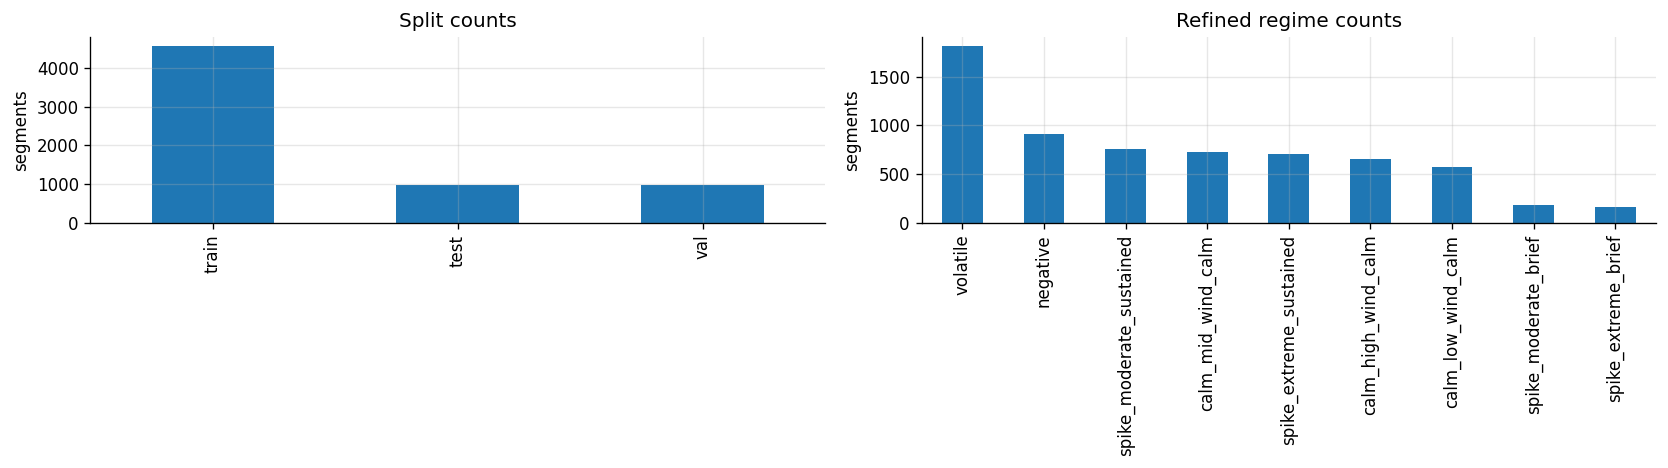

In [11]:
print("Rows by split:")
print(df_logsigs["split"].value_counts())

print("\nRows by refined regime:")
print(df_logsigs["regime"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_logsigs["split"].value_counts().plot(kind="bar", ax=axes[0], title="Split counts")
axes[0].set_xlabel("")
axes[0].set_ylabel("segments")

df_logsigs["regime"].value_counts().head(12).plot(kind="bar", ax=axes[1], title="Refined regime counts")
axes[1].set_xlabel("")
axes[1].set_ylabel("segments")

plt.tight_layout()
plt.savefig(DATA_DIR / "03_s3_split_and_regimes.png", bbox_inches="tight")
plt.show()

### CELL 10 — Depth ablation

In [12]:
depth_norms = {}
sample_n = min(200, len(df_logsigs))

for depth in range(1, SIG_DEPTH + 1):
    spec_d = iisignature.prepare(PATH_DIM, depth)
    dim_d = iisignature.logsiglength(PATH_DIM, depth)
    norms = []

    for i in range(sample_n):
        row = df_logsigs.iloc[i]
        s_idx = int(row["start_idx"])
        e_idx = int(row["end_idx"])
        p = pd.Series(prices[s_idx:e_idx]).ffill().bfill().to_numpy(dtype=np.float64)
        w = pd.Series(wind[s_idx:e_idx]).ffill().bfill().fillna(0.0).to_numpy(dtype=np.float64)
        path = build_path(p, w, use_lead_lag=USE_LEAD_LAG)
        ls = iisignature.logsig(path, spec_d)
        norms.append(np.linalg.norm(ls))

    depth_norms[depth] = {
        "dim": int(dim_d),
        "mean_norm": float(np.mean(norms)),
        "std_norm": float(np.std(norms)),
    }
    print(f"Depth {depth}: dim={dim_d:3d}, mean L2 norm={np.mean(norms):.4f} ± {np.std(norms):.4f}")

Depth 1: dim=  4, mean L2 norm=2.9883 ± 1.3310
Depth 2: dim= 10, mean L2 norm=27.1603 ± 11.5436
Depth 3: dim= 30, mean L2 norm=76.9725 ± 57.2918
Depth 4: dim= 90, mean L2 norm=231.2473 ± 263.1476


### CELL 11 — PCA regime separation check

PCA explained variance (2 comps): 24.1%


/tmp/ipykernel_2315/3775620927.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(len(regime_order), 3))


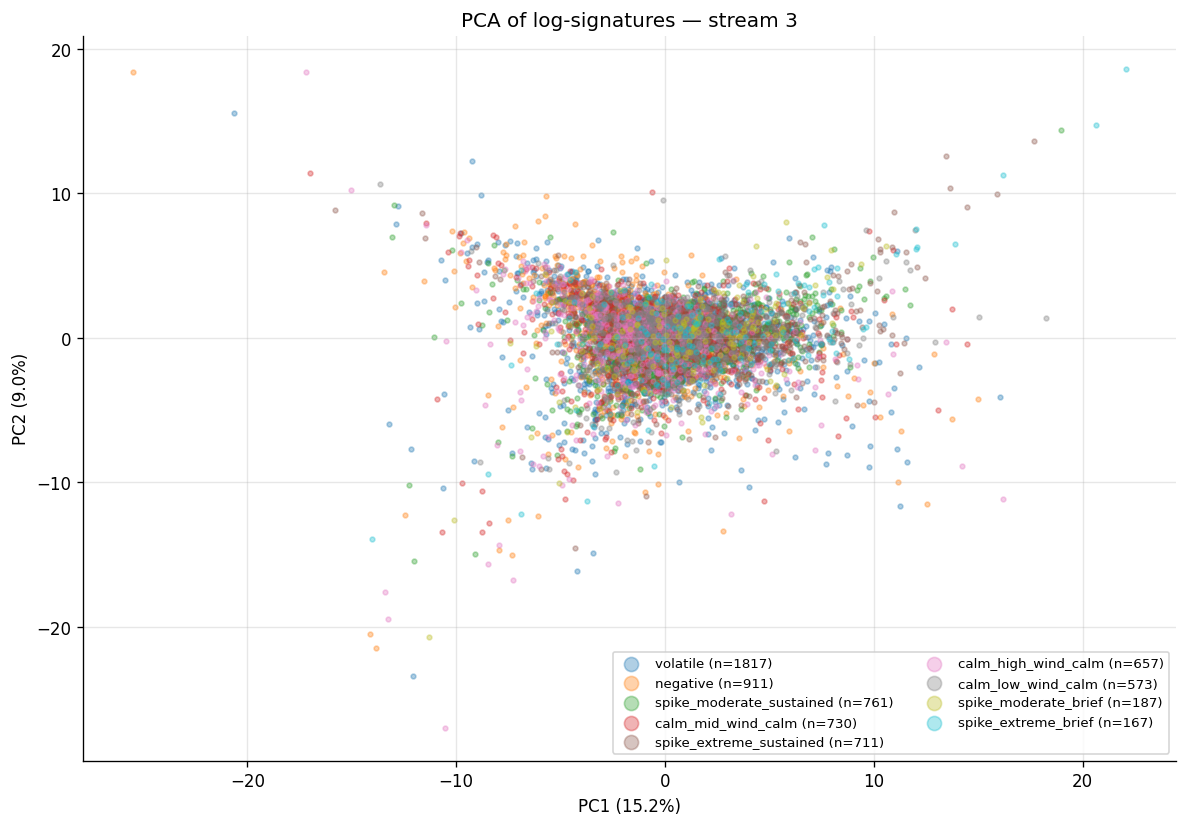

In [13]:
ls_cols = [c for c in df_logsigs.columns if c.startswith("ls_")]
X = df_logsigs[ls_cols].to_numpy(dtype=np.float64)

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std < 1e-8] = 1.0
X_norm = (X - X_mean) / X_std

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_norm)
print(f"PCA explained variance (2 comps): {100 * pca.explained_variance_ratio_.sum():.1f}%")

fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.cm.get_cmap("tab10", max(len(regime_order), 3))

for idx, regime_name in enumerate(regime_order):
    mask = df_logsigs["regime"] == regime_name
    n = int(mask.sum())
    if n == 0:
        continue
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=8,
        alpha=0.35,
        color=cmap(idx),
        label=f"{regime_name} (n={n})",
    )

ax.set_xlabel(f"PC1 ({100 * pca.explained_variance_ratio_[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({100 * pca.explained_variance_ratio_[1]:.1f}%)")
ax.set_title("PCA of log-signatures — stream 3")
ax.legend(markerscale=3, fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(DATA_DIR / "03_s3_signature_pca.png", bbox_inches="tight")
plt.show()

### CELL 12 — Lévy area vs realised volatility

Correlation |ls_7| vs realised vol: 0.1569


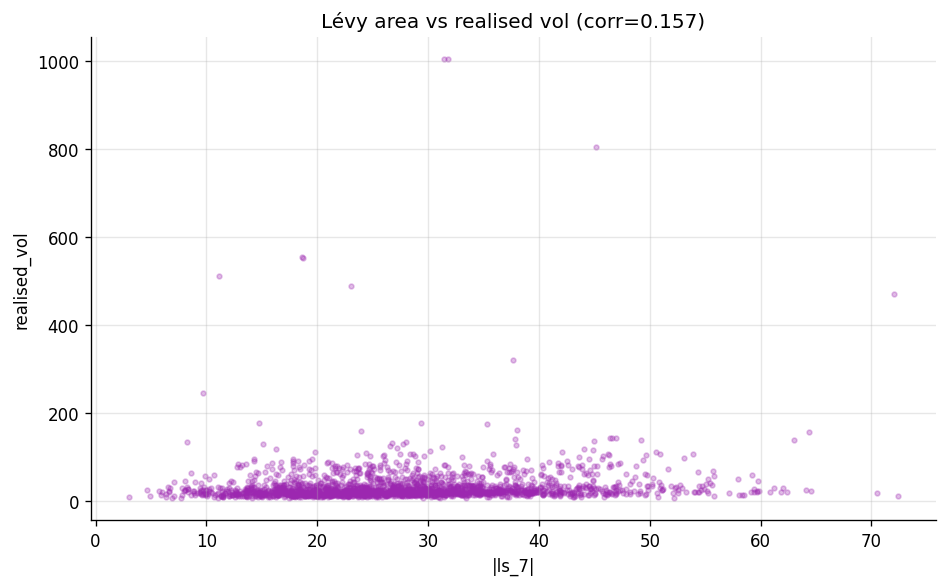

In [14]:
levy_col = f"ls_{LEVY_AREA_IDX}"
if levy_col in df_logsigs.columns:
    levy_area = pd.to_numeric(df_logsigs[levy_col], errors="coerce").to_numpy(dtype=np.float64)
    realised_vol = pd.to_numeric(df_logsigs["realised_vol"], errors="coerce").to_numpy(dtype=np.float64)

    corr_levy = np.corrcoef(np.abs(levy_area), realised_vol)[0, 1]
    print(f"Correlation |{levy_col}| vs realised vol: {corr_levy:.4f}")

    fig, ax = plt.subplots(figsize=(8, 5))
    sample_size = min(2000, len(df_logsigs))
    sample_idx = np.random.choice(len(df_logsigs), size=sample_size, replace=False)
    ax.scatter(
        np.abs(levy_area[sample_idx]),
        realised_vol[sample_idx],
        alpha=0.30,
        s=8,
        color="#9C27B0",
    )
    ax.set_xlabel(f"|{levy_col}|")
    ax.set_ylabel("realised_vol")
    ax.set_title(f"Lévy area vs realised vol (corr={corr_levy:.3f})")
    plt.tight_layout()
    plt.savefig(DATA_DIR / "03_s3_levy_area.png", bbox_inches="tight")
    plt.show()
else:
    print(f"{levy_col} not found; skipping plot.")

### CELL 13 — Save `_s3` artifacts for Notebook 4

In [16]:
# Save parquet with both logsig features and conditioning features
pl.from_pandas(df_logsigs).write_parquet(LOGSIG_OUT)
print(f"Saved: {LOGSIG_OUT.name}")
print(f"  Shape: {df_logsigs.shape}")
print(f"  Size:  {LOGSIG_OUT.stat().st_size / 1e6:.2f} MB")

norm_stats_s3 = {
    "stream_tag": STREAM_TAG,
    "price_col": PRICE_COL,
    "wind_col": WIND_COL,
    "path_dim": int(PATH_DIM),
    "sig_depth": int(SIG_DEPTH),
    "logsig_dim": int(logsig_dim),
    "levy_area_idx": int(LEVY_AREA_IDX),
    "segment_length": int(SEGMENT_LENGTH),
    "step_size": int(STEP_SIZE),
    "use_lead_lag": bool(USE_LEAD_LAG),
    "n_rows_saved": int(len(df_logsigs)),
    "n_train": int((df_logsigs["split"] == "train").sum()),
    "n_val": int((df_logsigs["split"] == "val").sum()),
    "n_test": int((df_logsigs["split"] == "test").sum()),
    "depth_norms": depth_norms,
}
with open(NORM_OUT, "w") as fp:
    json.dump(norm_stats_s3, fp, indent=2)
print(f"Saved: {NORM_OUT.name}")

split_summary = {}
for split_name in ["train", "val", "test"]:
    mask = df_logsigs["split"] == split_name
    if mask.any():
        sub = df_logsigs.loc[mask, ["start_idx", "start_time"]].copy()
        sub = sub.sort_values("start_idx")
        split_summary[split_name] = {
            "n_rows": int(mask.sum()),
            "start_idx_min": int(sub["start_idx"].min()),
            "start_idx_max": int(sub["start_idx"].max()),
            "start_time_min": str(pd.to_datetime(sub["start_time"]).min()),
            "start_time_max": str(pd.to_datetime(sub["start_time"]).max()),
        }

conditioning_stats_s3 = {
    "stream_tag": STREAM_TAG,
    "conditioning_dim": int(len(conditioning_cols)),
    "regime_col": REGIME_COL,
    "regime_order": regime_order,
    "econometric_scalar_cols_raw": ECON_COLS_TARGET,
    "econometric_scalar_cols_cond": cond_scalar_cols,
    "hazard_cols_raw": HAZARD_SEG_COLS,
    "hazard_cols_cond": cond_hazard_cols,
    "regime_onehot_cols": cond_regime_cols,
    "all_conditioning_cols": conditioning_cols,
    "scalar_stats": scalar_stats,
    "raw_scalar_missing_before_fill": raw_missing_before_fill,
    "hazard_stats_after_log1p": hazard_stats,
    "split_summary": split_summary,
    "source_feature_json_conditioning_variables": feature_analysis.get("conditioning_variables"),
    "har_restored_explicitly": True,
}
with open(COND_STATS_OUT, "w") as fp:
    json.dump(conditioning_stats_s3, fp, indent=2)
print(f"Saved: {COND_STATS_OUT.name}")

print("\nNotebook 4 read path:")
print(f"  {LOGSIG_OUT.name}")
print("\nColumns for Notebook 4:")
print(f"  log-signatures: {len(ls_cols)}")
print(f"  conditioning:   {len(conditioning_cols)}")
print(f"  split/meta:     {len([c for c in ['segment_id', 'start_time', 'start_idx', 'end_idx', 'split', 'regime'] if c in df_logsigs.columns])}")

Saved: logsigs_s3.parquet
  Shape: (6514, 132)
  Size:  5.57 MB
Saved: norm_stats_s3.json
Saved: conditioning_stats_s3.json

Notebook 4 read path:
  logsigs_s3.parquet

Columns for Notebook 4:
  log-signatures: 90
  conditioning:   19
  split/meta:     6


### CELL 14 — Targeted reruns
- If you change path construction or signature depth: rerun Cells 7–13.
- If you change scalar / hazard conditioning only: rerun Cells 5–13.
- If you only change plots: rerun the relevant plot cell(s) plus Cell 13 if you want the saved figures refreshed.